In [150]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot  as plt
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor


In [119]:
data = pd.read_csv('Mall_Customers.csv')
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [120]:
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [121]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [122]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [123]:
data.drop('CustomerID',axis=1,inplace=True)

In [124]:
mapping = {'Male':0,'Female':1}
data['Gender'] = (data['Gender'] .map(mapping)).astype('int8')

In [125]:
data['Age'] = data['Age'].astype('int8')

array([[<Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Income (k$)'}>,
        <Axes: title={'center': 'Spending Score (1-100)'}>]], dtype=object)

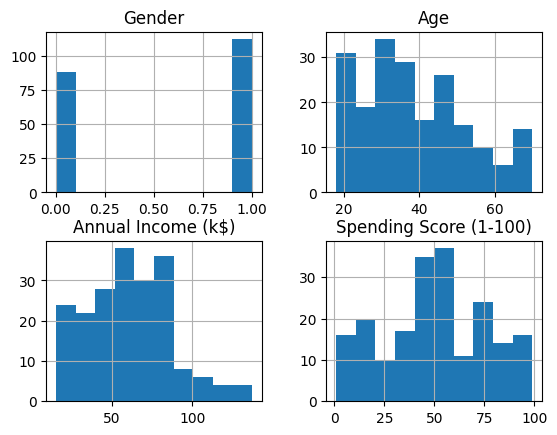

In [24]:
data.hist()

In [26]:
sc = StandardScaler()

In [35]:
scaler_features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X_scaled = sc.fit_transform(scaler_features)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


<h1>Unsupervised learning</h1>

In [91]:
model = KMeans(n_clusters=5,random_state=42,n_init=5,max_iter=100)

In [92]:
y_kmeans = model.fit_predict(X_scaled)

In [93]:
centers1 = model.cluster_centers_
centers1

array([[ 0.5310735 , -1.2905084 , -1.23646671],
       [-0.98067852, -0.74305983,  0.46744035],
       [-0.42880597,  0.97484722,  1.21608539],
       [ 0.07333084,  0.97494509, -1.19729675],
       [ 1.20484056, -0.23577338, -0.05236781]])

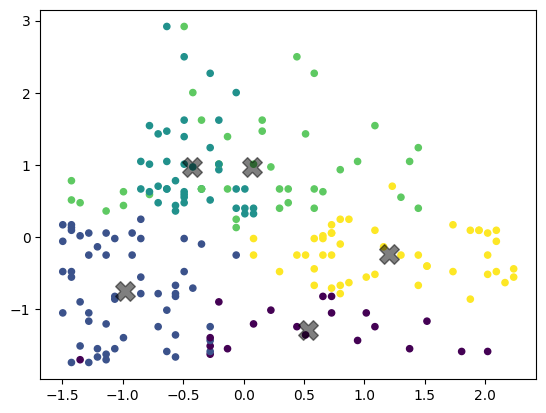

[[ 0.5310735  -1.2905084  -1.23646671]
 [-0.98067852 -0.74305983  0.46744035]
 [-0.42880597  0.97484722  1.21608539]
 [ 0.07333084  0.97494509 -1.19729675]
 [ 1.20484056 -0.23577338 -0.05236781]]


In [96]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, s=20, cmap='viridis')

centers = model.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5, marker='X')

plt.show()
print(centers)

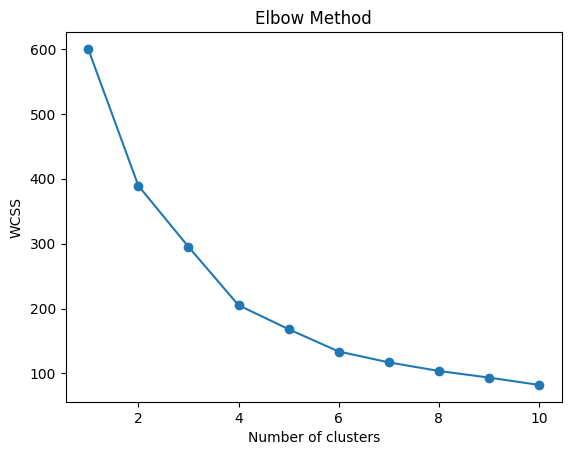

In [90]:

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=5,max_iter=100)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

<h1>Supervised learning</h1>

In [127]:
X = data.drop('Spending Score (1-100)',axis=1)
y = data['Spending Score (1-100)']

In [128]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [129]:
sc = StandardScaler()


X_scaled_train = sc.fit_transform(X_train)
X_scaled_test = sc.transform(X_test)

In [130]:
lmodel = LinearRegression()
lmodel.fit(X_scaled_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [131]:
predict = model.predict(X_scaled_test)

In [132]:
predict

array([0, 0, 3, 0, 3, 4, 4, 0, 1, 4, 2, 0, 1, 4, 1, 0, 2, 1, 3, 0, 1, 4,
       1, 2, 0, 3, 4, 2, 1, 1, 4, 3, 3, 0, 0, 3, 1, 0, 3, 2], dtype=int32)

In [133]:
mse = mean_squared_error(y_test,predict)

In [134]:
mse

2267.375

In [135]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


In [149]:
randomforest = RandomForestRegressor(random_state=42,)
randomforest.fit(X_scaled_train,y_train)
predict = randomforest.predict(X_scaled_test)
mse = mean_squared_error(y_test,predict)
mse

458.73179225972234

In [153]:
pmodel = PolynomialFeatures(degree=2)
X_train_poly = pmodel.fit_transform(X_scaled_train)
X_test_poly = pmodel.transform(X_scaled_test)

lmodel = LinearRegression()
lmodel.fit(X_train_poly,y_train)
predict = lmodel.predict(X_test_poly)
mse = mean_squared_error(y_test,predict)
mse

526.981292091142